In [ ]:
# prompt: import data science libraries, sns set theme, mount drive

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

sns.set_theme()

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_path = '/content/drive/My Drive/DSO 574/assignments/assignment data/NBA Data/'

In [ ]:
files = os.listdir(data_path + 'Combined Files [With Game ID]')
files

['2016-2017_NBA_PbP_Logs.csv',
 '2014-2015_NBA_PbP_Logs.csv',
 '2013-2014_NBA_PbP_Logs.csv',
 '2015-2016_NBA_PbP_Logs.csv',
 '2021-2022_NBA_PbP_Logs.csv',
 '2017-2018_NBA_PbP_Logs.csv',
 '2019-2020_NBA_PbP_Logs.csv',
 '2022-2023_NBA_PbP_Logs.csv',
 '2018-2019_NBA_PbP_Logs.csv',
 '2020-2021_NBA_PbP_Logs.csv',
 '2023-2024_NBA_PbP_Logs.csv']

In [ ]:
df = pd.read_csv(data_path + 'Combined Files [With Game ID]/2014-2015_NBA_PbP_Logs.csv')

In [ ]:
new_orleans = df[df['matchup'].apply(lambda x: 'NOP' in x)].copy()
new_orleans['ad_on'] = (new_orleans.iloc[:, 3:14] == 'Anthony Davis').sum(axis=1).astype(bool)
new_orleans['NOP_offense'] = new_orleans.team == 'NOP'
new_orleans['game_min'] = new_orleans.elapsed.apply(lambda x: int(x.split(':')[1]))
new_orleans

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,original_x,original_y,converted_x,converted_y,description,matchup,game_name,ad_on,NOP_offense,game_min
4480,21400323,2014-15 Regular Season,2014-12-10,Anthony Davis,Omer Asik,Jrue Holiday,Luke Babbitt,Tyreke Evans,Tyson Chandler,J.J. Barea,...,NaN,NaN,NaN,NaN,NaN,NOP@DAL,0021400323-NOP@DAL,True,False,0
4481,21400323,2014-15 Regular Season,2014-12-10,Anthony Davis,Omer Asik,Jrue Holiday,Luke Babbitt,Tyreke Evans,Tyson Chandler,J.J. Barea,...,NaN,NaN,NaN,NaN,Jump Ball Chandler vs. Davis: Tip to Barea,NOP@DAL,0021400323-NOP@DAL,True,False,0
4482,21400323,2014-15 Regular Season,2014-12-10,Anthony Davis,Omer Asik,Jrue Holiday,Luke Babbitt,Tyreke Evans,Tyson Chandler,J.J. Barea,...,9.0,98.0,25.9,79.2,MISS Ellis 10' Jump Shot,NOP@DAL,0021400323-NOP@DAL,True,False,0
4483,21400323,2014-15 Regular Season,2014-12-10,Anthony Davis,Omer Asik,Jrue Holiday,Luke Babbitt,Tyreke Evans,Tyson Chandler,J.J. Barea,...,NaN,NaN,NaN,NaN,Asik REBOUND (Off:0 Def:1),NOP@DAL,0021400323-NOP@DAL,True,True,0
4484,21400323,2014-15 Regular Season,2014-12-10,Anthony Davis,Omer Asik,Jrue Holiday,Luke Babbitt,Tyreke Evans,Tyson Chandler,J.J. Barea,...,-168.0,121.0,41.8,17.1,Davis 21' Jump Shot (2 PTS) (Holiday 1 AST),NOP@DAL,0021400323-NOP@DAL,True,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600094,21400311,2014-15 Regular Season,2014-12-09,Amar'e Stoudemire,JR Smith,Pablo Prigioni,Jose Calderon,Carmelo Anthony,Tyreke Evans,Dante Cunningham,...,NaN,NaN,NaN,NaN,Asik Free Throw 1 of 2 (16 PTS),NYK@NOP,0021400311-NYK@NOP,True,True,11
600095,21400311,2014-15 Regular Season,2014-12-09,Amar'e Stoudemire,JR Smith,Pablo Prigioni,Jose Calderon,Carmelo Anthony,Tyreke Evans,Dante Cunningham,...,NaN,NaN,NaN,NaN,MISS Asik Free Throw 2 of 2,NYK@NOP,0021400311-NYK@NOP,True,True,11
600096,21400311,2014-15 Regular Season,2014-12-09,Cole Aldrich,JR Smith,Pablo Prigioni,Jose Calderon,Carmelo Anthony,Tyreke Evans,Dante Cunningham,...,NaN,NaN,NaN,NaN,Anthony REBOUND (Off:1 Def:7),NYK@NOP,0021400311-NYK@NOP,True,False,11
600097,21400311,2014-15 Regular Season,2014-12-09,Cole Aldrich,JR Smith,Pablo Prigioni,Jose Calderon,Carmelo Anthony,Tyreke Evans,Dante Cunningham,...,-15.0,9.0,26.5,5.9,Smith 2' Driving Layup (17 PTS),NYK@NOP,0021400311-NYK@NOP,True,False,11


In [ ]:
new_orleans.columns

Index(['game_id', 'data_set', 'date', 'a1', 'a2', 'a3', 'a4', 'a5', 'h1', 'h2',
       'h3', 'h4', 'h5', 'period', 'away_score', 'home_score',
       'remaining_time', 'elapsed', 'play_length', 'play_id', 'team',
       'event_type', 'assist', 'away', 'home', 'block', 'entered', 'left',
       'num', 'opponent', 'outof', 'player', 'points', 'possession', 'reason',
       'result', 'steal', 'type', 'shot_distance', 'original_x', 'original_y',
       'converted_x', 'converted_y', 'description', 'matchup', 'game_name',
       'ad_on', 'NOP_offense', 'game_min'],
      dtype='object')

## Kyrie to the Mavs Effect on Doncic

In [ ]:
years = ['2021-2022_NBA_PbP_Logs.csv', '2022-2023_NBA_PbP_Logs.csv', '2023-2024_NBA_PbP_Logs.csv']
mavs = pd.DataFrame()
for y in years:
  data = pd.read_csv(data_path + 'Combined Files [With Game ID]/' + y)
  mavs = pd.concat([mavs, data[data['matchup'].apply(lambda x: 'DAL' in x)]])
mavs

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,steal,type,shot_distance,original_x,original_y,converted_x,converted_y,description,matchup,game_name
5491,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NaN,start of period,NaN,NaN,NaN,NaN,NaN,NaN,NOP@DAL,0022100338-NOP@DAL
5492,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NaN,jump ball,NaN,NaN,NaN,NaN,NaN,Jump Ball Powell vs. Valanciunas: Tip to Jones,NOP@DAL,0022100338-NOP@DAL
5493,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NaN,driving reverse layup,2.0,16.0,12.0,23.4,6.2,MISS Jones 2' Driving Reverse Layup,NOP@DAL,0022100338-NOP@DAL
5494,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NaN,rebound offensive,NaN,NaN,NaN,NaN,NaN,Temple REBOUND (Off:1 Def:0),NOP@DAL,0022100338-NOP@DAL
5495,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NaN,3pt jump shot,25.0,112.0,227.0,13.8,27.7,MISS Ingram 25' 3PT Jump Shot,NOP@DAL,0022100338-NOP@DAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606987,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,NaN,3pt step back jump shot,26.0,-172.0,199.0,42.2,24.9,MISS Doncic 26' 3PT Step Back Jump Shot,DAL@POR,0022301226-DAL@POR
606988,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,NaN,rebound defensive,NaN,NaN,NaN,NaN,NaN,Henderson REBOUND (Off:1 Def:2),DAL@POR,0022301226-DAL@POR
606989,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,NaN,3pt step back jump shot,25.0,-47.0,250.0,20.3,64.0,MISS Henderson 25' 3PT Step Back Jump Shot,DAL@POR,0022301226-DAL@POR
606990,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,NaN,team rebound,NaN,NaN,NaN,NaN,NaN,TRAIL BLAZERS Rebound,DAL@POR,0022301226-DAL@POR


In [ ]:
mavs['luka_on'] = (mavs.iloc[:, 3:14] == 'Luka Doncic').sum(axis=1).astype(bool)
mavs['DAL_offense'] = mavs.team == 'DAL'
mavs['game_min'] = mavs.elapsed.apply(lambda x: int(x.split(':')[1]))
mavs['period_min'] = mavs.period.astype(str) + '_' + mavs.game_min.astype(str)
mavs['description'] = mavs.description.astype(str)

In [ ]:
mavs

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,original_y,converted_x,converted_y,description,matchup,game_name,luka_on,DAL_offense,game_min,period_min
5491,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NaN,NaN,NaN,nan,NOP@DAL,0022100338-NOP@DAL,True,False,0,1_0
5492,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NaN,NaN,NaN,Jump Ball Powell vs. Valanciunas: Tip to Jones,NOP@DAL,0022100338-NOP@DAL,True,True,0,1_0
5493,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,12.0,23.4,6.2,MISS Jones 2' Driving Reverse Layup,NOP@DAL,0022100338-NOP@DAL,True,False,0,1_0
5494,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NaN,NaN,NaN,Temple REBOUND (Off:1 Def:0),NOP@DAL,0022100338-NOP@DAL,True,False,0,1_0
5495,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,227.0,13.8,27.7,MISS Ingram 25' 3PT Jump Shot,NOP@DAL,0022100338-NOP@DAL,True,False,0,1_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606987,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,199.0,42.2,24.9,MISS Doncic 26' 3PT Step Back Jump Shot,DAL@POR,0022301226-DAL@POR,True,True,11,4_11
606988,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,NaN,NaN,NaN,Henderson REBOUND (Off:1 Def:2),DAL@POR,0022301226-DAL@POR,True,False,11,4_11
606989,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,250.0,20.3,64.0,MISS Henderson 25' 3PT Step Back Jump Shot,DAL@POR,0022301226-DAL@POR,True,False,12,4_12
606990,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,NaN,NaN,NaN,TRAIL BLAZERS Rebound,DAL@POR,0022301226-DAL@POR,True,False,12,4_12


In [ ]:
# prompt: generate pivot table on 'db_on', 'PHX_offense', and 'period_min' summing 'home_score' and 'away_score'

pivot_table = pd.pivot_table(mavs, values=['home_score', 'away_score'], index=['luka_on', 'data_set', 'period_min'], aggfunc='sum').reset_index()
pivot_table['plus_minus'] = pivot_table['home_score'] - pivot_table['away_score']
pivot_table

,luka_on,data_set,period_min,away_score,home_score,plus_minus
0,False,2021-22 Playoffs,1_0,7,27,20
1,False,2021-22 Playoffs,1_1,68,52,-16
2,False,2021-22 Playoffs,1_10,847,835,-12
3,False,2021-22 Playoffs,1_11,1022,1117,95
4,False,2021-22 Playoffs,1_12,261,292,31
...,...,...,...,...,...,...
623,True,NBA 2024 Playoffs,4_5,17611,18754,1143
624,True,NBA 2024 Playoffs,4_6,17272,17766,494
625,True,NBA 2024 Playoffs,4_7,14635,14855,220
626,True,NBA 2024 Playoffs,4_8,13432,13442,10


<ipython-input-11-df22928323c2>:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset['plus_minus'], label=f'Luka on: {luka_on_value}', shade=True)
<ipython-input-11-df22928323c2>:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset['plus_minus'], label=f'Luka on: {luka_on_value}', shade=True)


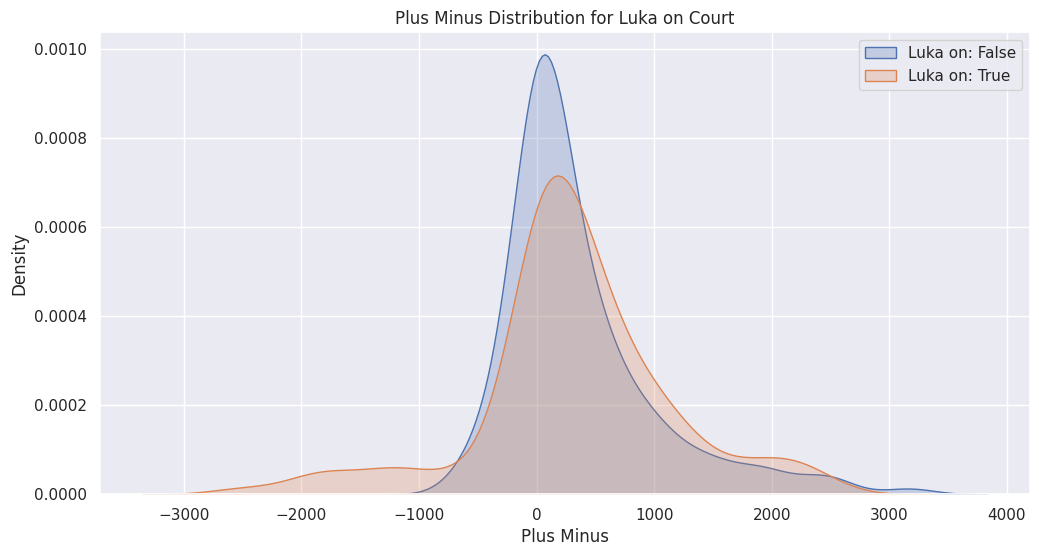

In [ ]:
# prompt: # prompt:  plot plus minus distribution for both values of luka_on on the same plot, remove the bars for each data_set. Assuming pivot_table is defined as in your previous code

# Assuming pivot_table is defined as in the previous code

plt.figure(figsize=(12, 6))

for luka_on_value in pivot_table['luka_on'].unique():
    subset = pivot_table[pivot_table['luka_on'] == luka_on_value]
    sns.kdeplot(subset['plus_minus'], label=f'Luka on: {luka_on_value}', shade=True)

plt.title('Plus Minus Distribution for Luka on Court')
plt.xlabel('Plus Minus')
plt.ylabel('Density')
plt.legend()
plt.show()


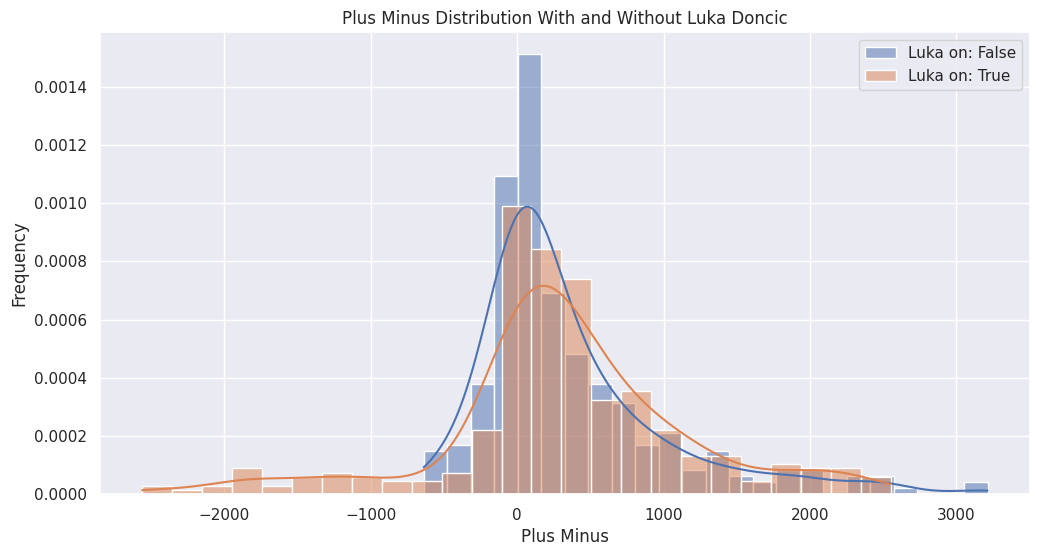

In [ ]:
# prompt:  plot plus minus distribution for both values of db_on on the same plot, remove the bars for each data_set

# Assuming pivot_table is defined as in your previous code

plt.figure(figsize=(12, 6))

for luka_on_value in pivot_table['luka_on'].unique():
    subset = pivot_table[pivot_table['luka_on'] == luka_on_value]
    sns.histplot(subset['plus_minus'], label=f'Luka on: {luka_on_value}', kde=True, stat='density')

plt.xlabel('Plus Minus')
plt.ylabel('Frequency')
plt.title('Plus Minus Distribution With and Without Luka Doncic')
plt.legend()
plt.show()


### DAL Shot Percentage With and Without Luka, With and Without Kyrie During Regular Season

In [ ]:
mavs['kyrie_on'] = (mavs.iloc[:, 3:14] == 'Kyrie Irving').sum(axis=1).astype(bool)

In [ ]:
# regular season
mavs_off = mavs[(mavs.DAL_offense) & (mavs.data_set.astype(str).apply(lambda x: 'Regular' in x))].copy()
mavs_off['misses'] = mavs_off.description.apply(lambda x: 'MISS' in x)
mavs_off['makes'] = mavs_off.description.apply(lambda x: 'PTS' in x) & mavs_off.description.astype(str).apply(lambda x: 'Free Throw' not in x)
mavs_off.head()

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,description,matchup,game_name,luka_on,DAL_offense,game_min,period_min,kyrie_on,misses,makes
5492,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,Jump Ball Powell vs. Valanciunas: Tip to Jones,NOP@DAL,0022100338-NOP@DAL,True,True,0,1_0,False,False,False
5496,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,Bullock REBOUND (Off:0 Def:1),NOP@DAL,0022100338-NOP@DAL,True,True,0,1_0,False,False,False
5497,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,MISS Doncic 26' 3PT Jump Shot,NOP@DAL,0022100338-NOP@DAL,True,True,0,1_0,False,True,False
5499,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,Bullock P.FOUL (P1.T1) (T.Brothers),NOP@DAL,0022100338-NOP@DAL,True,True,0,1_0,False,False,False
5501,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,Doncic REBOUND (Off:0 Def:1),NOP@DAL,0022100338-NOP@DAL,True,True,1,1_1,False,False,False


In [ ]:
# prompt: generate pivot table for suns_off for db_on and sum of misses and makes
pivot_table_mavs_off_no_kyrie = pd.pivot_table(mavs_off[~mavs_off.kyrie_on], values=['misses', 'makes'], index=['luka_on', 'period_min'], aggfunc='sum').reset_index()
pivot_table_mavs_off_no_kyrie['shots'] = pivot_table_mavs_off_no_kyrie['misses'] + pivot_table_mavs_off_no_kyrie['makes']
pivot_table_mavs_off_no_kyrie['shot_pct'] = pivot_table_mavs_off_no_kyrie['makes'] / pivot_table_mavs_off_no_kyrie['shots']
pivot_table_mavs_off_no_kyrie

,luka_on,period_min,makes,misses,shots,shot_pct
0,False,1_0,21,28,49,0.428571
1,False,1_1,24,46,70,0.342857
2,False,1_10,59,82,141,0.418440
3,False,1_11,66,66,132,0.500000
4,False,1_12,3,20,23,0.130435
...,...,...,...,...,...,...
116,True,6_0,1,1,2,0.500000
117,True,6_1,0,1,1,0.000000
118,True,6_2,2,1,3,0.666667
119,True,6_3,1,1,2,0.500000


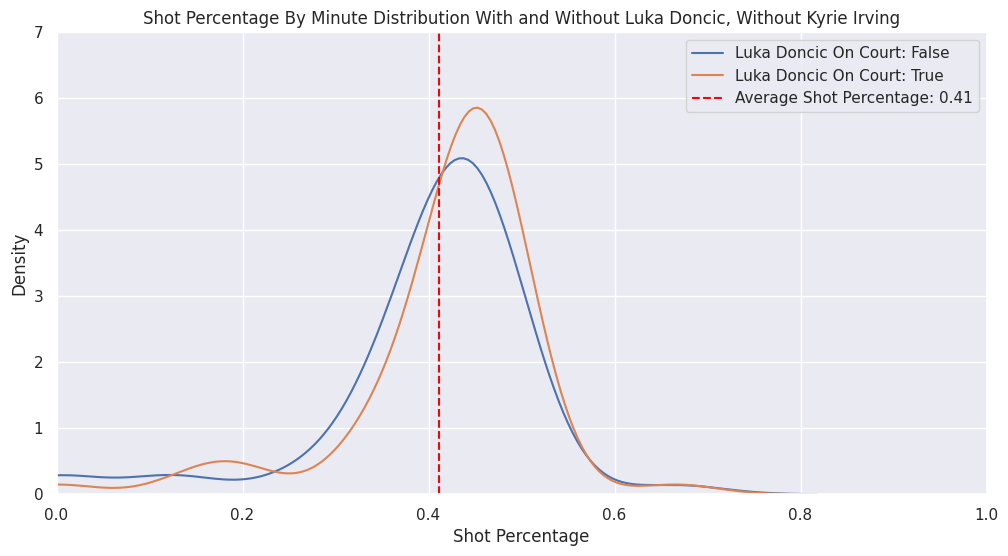

In [ ]:
plt.figure(figsize=(12, 6))

for luka_on_value in pivot_table_mavs_off_no_kyrie['luka_on'].unique():
  subset = pivot_table_mavs_off_no_kyrie[pivot_table_mavs_off_no_kyrie['luka_on'] == luka_on_value]
  sns.kdeplot(subset['shot_pct'], label=f'Luka Doncic On Court: {luka_on_value}')

avg_shot_pct = pivot_table_mavs_off_no_kyrie['shot_pct'].mean()
plt.axvline(x=avg_shot_pct, color='red', linestyle='--', label=f'Average Shot Percentage: {avg_shot_pct:.2f}')

plt.xlabel('Shot Percentage')
plt.xlim(0, 1)
plt.ylabel('Density')
plt.ylim(0, 7)
plt.title('Shot Percentage By Minute Distribution With and Without Luka Doncic, Without Kyrie Irving')
plt.legend()
plt.show()

In [ ]:
 # with kyrie
pivot_table_mavs_off_kyrie = pd.pivot_table(mavs_off[mavs_off.kyrie_on], values=['misses', 'makes'], index=['luka_on', 'period_min'], aggfunc='sum').reset_index()
pivot_table_mavs_off_kyrie['shots'] = pivot_table_mavs_off_kyrie['misses'] + pivot_table_mavs_off_kyrie['makes']
pivot_table_mavs_off_kyrie['shot_pct'] = pivot_table_mavs_off_kyrie['makes'] / pivot_table_mavs_off_kyrie['shots']
pivot_table_mavs_off_kyrie

,luka_on,period_min,makes,misses,shots,shot_pct
0,False,1_0,8,9,17,0.470588
1,False,1_1,10,12,22,0.454545
2,False,1_10,36,53,89,0.404494
3,False,1_11,36,37,73,0.493151
4,False,1_12,4,6,10,0.400000
...,...,...,...,...,...,...
105,True,5_1,3,3,6,0.500000
106,True,5_2,3,3,6,0.500000
107,True,5_3,3,4,7,0.428571
108,True,5_4,7,3,10,0.700000


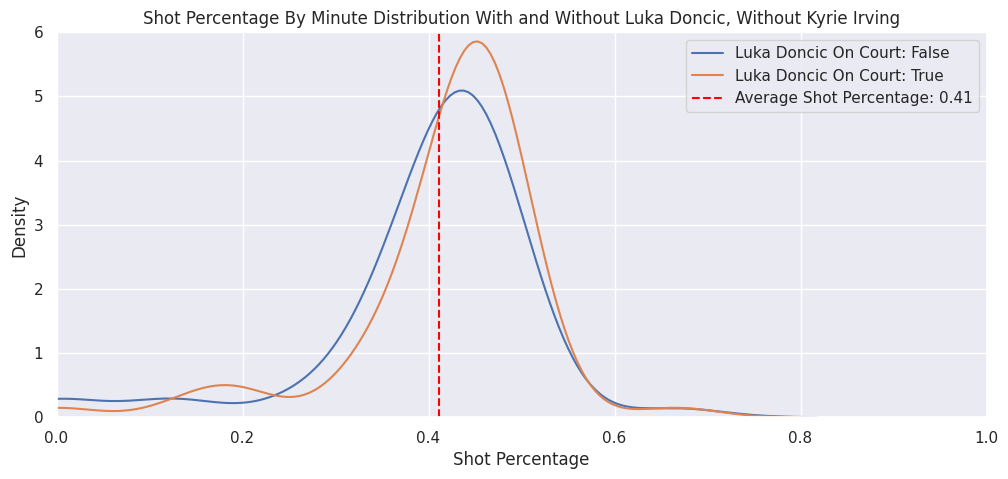

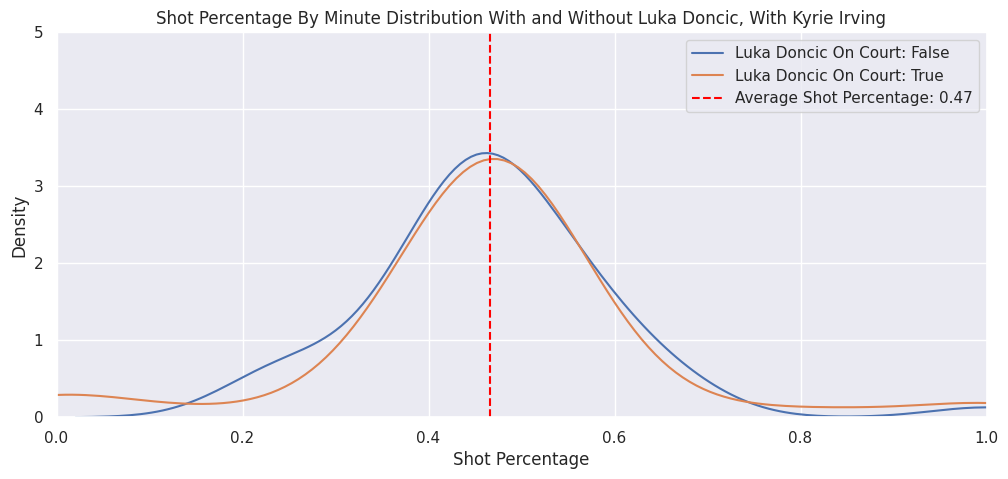

In [ ]:
plt.figure(figsize=(12, 5))

for luka_on_value in pivot_table_mavs_off_no_kyrie['luka_on'].unique():
  subset = pivot_table_mavs_off_no_kyrie[pivot_table_mavs_off_no_kyrie['luka_on'] == luka_on_value]
  sns.kdeplot(subset['shot_pct'], label=f'Luka Doncic On Court: {luka_on_value}')

avg_shot_pct = pivot_table_mavs_off_no_kyrie['shot_pct'].mean()
plt.axvline(x=avg_shot_pct, color='red', linestyle='--', label=f'Average Shot Percentage: {avg_shot_pct:.2f}')

plt.xlabel('Shot Percentage')
plt.xlim(0, 1)
plt.ylabel('Density')
plt.ylim(0, 6)
plt.title('Shot Percentage By Minute Distribution With and Without Luka Doncic, Without Kyrie Irving')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))

for luka_on_value in pivot_table_mavs_off_kyrie['luka_on'].unique():
  subset = pivot_table_mavs_off_kyrie[pivot_table_mavs_off_kyrie['luka_on'] == luka_on_value]
  sns.kdeplot(subset['shot_pct'], label=f'Luka Doncic On Court: {luka_on_value}')

avg_shot_pct = pivot_table_mavs_off_kyrie['shot_pct'].mean()
plt.axvline(x=avg_shot_pct, color='red', linestyle='--', label=f'Average Shot Percentage: {avg_shot_pct:.2f}')

plt.xlabel('Shot Percentage')
plt.xlim(0, 1)
plt.ylabel('Density')
plt.ylim(0, 5)
plt.title('Shot Percentage By Minute Distribution With and Without Luka Doncic, With Kyrie Irving')
plt.legend()
plt.show()

### Dbook Shot Distribution With and Without KD - 2022-2024

In [ ]:
doncic_off_2224 = mavs_off[(mavs_off.luka_on) & (mavs_off.data_set.astype(str).apply(lambda x: '23' in x))].copy()
# get only plays where doncic is involved in the action
doncic_off_2224 = doncic_off_2224[doncic_off_2224.description.apply(lambda x: 'Doncic' in x)]

In [ ]:
doncic_off_2224['luka_shot'] = (doncic_off_2224.description.apply(lambda x: '(Doncic' not in x)) \
      & (doncic_off_2224['type'].apply(lambda x: 'shot' in x or 'layup' in x or 'fadeaway' in x or 'dunk' in x))

In [ ]:
doncic_shot_2224 = doncic_off_2224[(doncic_off_2224.luka_shot) | (doncic_off_2224['type'].apply(lambda x: 'free throw' in x or 'technical' in x))].copy()
doncic_shot_2224['FT'] = doncic_shot_2224['type'].apply(lambda x: 'free throw' in x or 'technical' in x)
doncic_shot_2224['FT_make'] = (doncic_shot_2224.FT) & (doncic_shot_2224.description.apply(lambda x: 'MISS' not in x))
doncic_shot_2224['shot'] = ~doncic_shot_2224.FT
doncic_shot_2224['shot_make'] = doncic_shot_2224.shot & (doncic_shot_2224.description.apply(lambda x: 'MISS' not in x))

In [ ]:
doncic_shot_2224['3PT'] = ((doncic_shot_2224.shot_distance >= 22) & (doncic_shot_2224['type'].apply(lambda x: '3pt' in x)))
doncic_shot_2224['midrange'] = ((doncic_shot_2224.shot_distance <= 24) & (doncic_shot_2224.shot_distance > 10) & (doncic_shot_2224['type'].apply(lambda x: '3pt' not in x)))
doncic_shot_2224['close'] = (doncic_shot_2224.shot_distance <= 10)

In [ ]:
# prompt: make a pivot for each shot distance category ('3PT', 'midrange', and 'close'), kyrie_on and summing shot and shot make

pivot_table_shot_distribution = pd.pivot_table(doncic_shot_2224, values=['shot', 'shot_make'],
                                              index=['kyrie_on', '3PT', 'midrange', 'close', 'period_min'],
                                              aggfunc='sum').reset_index()

pivot_table_shot_distribution

,kyrie_on,3PT,midrange,close,period_min,shot,shot_make
0,False,False,False,False,1_1,0,0
1,False,False,False,False,1_10,0,0
2,False,False,False,False,1_11,0,0
3,False,False,False,False,1_12,0,0
4,False,False,False,False,1_2,0,0
...,...,...,...,...,...,...,...
404,True,True,False,False,4_9,6,3
405,True,True,False,False,5_1,1,0
406,True,True,False,False,5_2,1,0
407,True,True,False,False,5_4,1,0


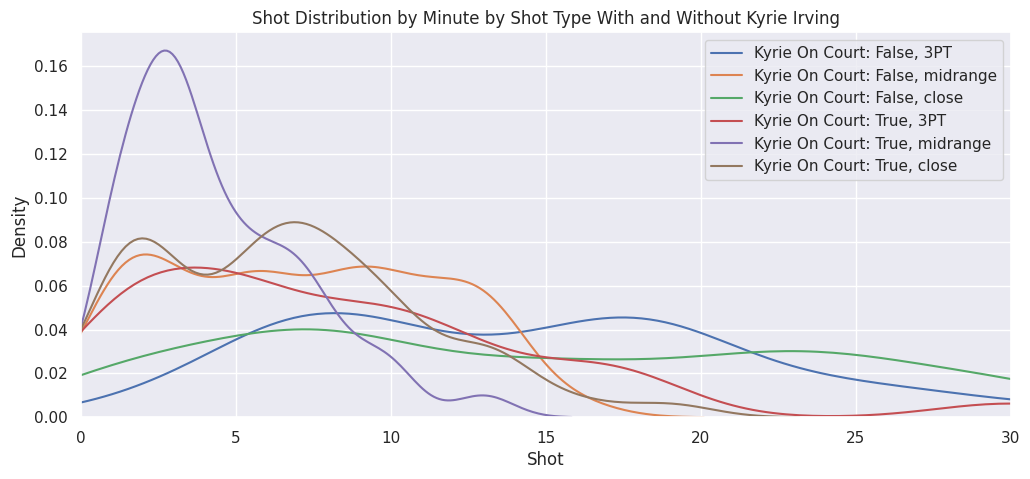

In [ ]:
# prompt: plot 'shot' kde distribution for kyrie on and off, normalizing y axis, for each category of shot

plt.figure(figsize=(12, 5))

for kyrie_on_value in pivot_table_shot_distribution['kyrie_on'].unique():
  for shot_type in ['3PT', 'midrange', 'close']:
    subset = pivot_table_shot_distribution[(pivot_table_shot_distribution['kyrie_on'] == kyrie_on_value) & (pivot_table_shot_distribution[shot_type])]
    if not subset.empty:
      shot_pct = subset['shot_make'] / subset['shot']
      sns.kdeplot(subset['shot'], bw_adjust=0.7, label=f'Kyrie On Court: {kyrie_on_value}, {shot_type}')


plt.xlabel('Shot')
plt.xlim(0, 30)
plt.ylabel('Density')
plt.title('Shot Distribution by Minute by Shot Type With and Without Kyrie Irving')
plt.legend()
plt.show()


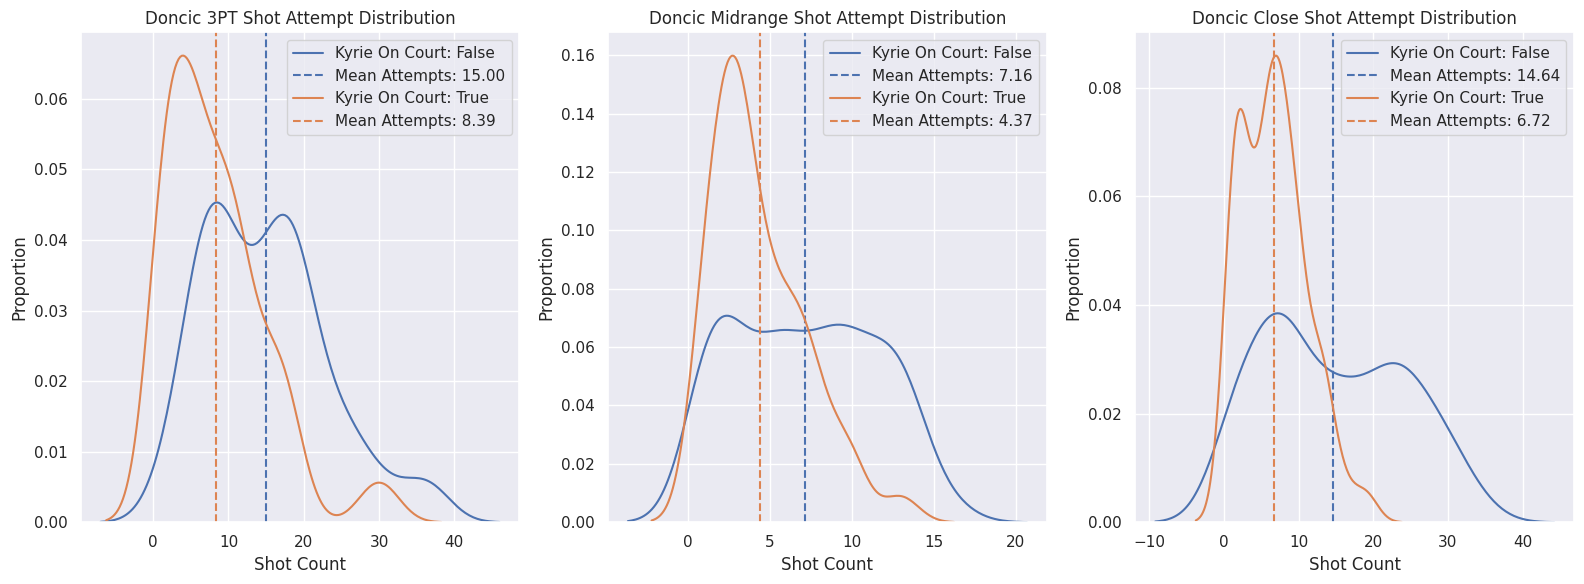

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))

for kyrie_on_value in pivot_table_shot_distribution['kyrie_on'].unique():

    # Subplot for 3PT shots
    plt.subplot(1, 3, 1)
    for shot_type in ['3PT']:
        subset = pivot_table_shot_distribution[
            (pivot_table_shot_distribution['kyrie_on'] == kyrie_on_value) &
            (pivot_table_shot_distribution[shot_type] == True)
        ]
        if not subset.empty:
            shot_pct = subset['shot_make'] / subset['shot']
            weights = [1 / len(subset)] * len(subset)  # Normalize each group equally
            sns.kdeplot(
                  x=subset['shot'],  # Explicitly pass Series as x
                  bw_adjust=0.8,
                  weights=[1 / len(subset)] * len(subset),
                  label=f'Kyrie On Court: {kyrie_on_value}'
              )
            mean_shot = subset['shot'].mean()
            plt.axvline(x=mean_shot, color='C1' if kyrie_on_value else 'C0',
                        linestyle='--', label=f'Mean Attempts: {mean_shot:.2f}')
    plt.xlabel('Shot Count')
    plt.ylabel('Proportion')
    plt.title('Doncic 3PT Shot Attempt Distribution')
    plt.legend()

    # Subplot for midrange shots
    plt.subplot(1, 3, 2)
    for shot_type in ['midrange']:
        subset = pivot_table_shot_distribution[
            (pivot_table_shot_distribution['kyrie_on'] == kyrie_on_value) &
            (pivot_table_shot_distribution[shot_type] == True)
        ]
        if not subset.empty:
            weights = [1 / len(subset)] * len(subset)
            sns.kdeplot(
                x=subset['shot'],  # Explicitly pass Series as x
                bw_adjust=0.8,
                weights=[1 / len(subset)] * len(subset),
                label=f'Kyrie On Court: {kyrie_on_value}'
            )
            mean_shot = subset['shot'].mean()
            plt.axvline(x=mean_shot, color='C1' if kyrie_on_value else 'C0',
                        linestyle='--', label=f'Mean Attempts: {mean_shot:.2f}')
    plt.xlabel('Shot Count')
    plt.ylabel('Proportion')
    plt.title('Doncic Midrange Shot Attempt Distribution')
    plt.legend()

    # Subplot for close shots
    plt.subplot(1, 3, 3)
    for shot_type in ['close']:
        subset = pivot_table_shot_distribution[
            (pivot_table_shot_distribution['kyrie_on'] == kyrie_on_value) &
            (pivot_table_shot_distribution[shot_type] == True)
        ]
        if not subset.empty:
            weights = [1 / len(subset)] * len(subset)
            sns.kdeplot(
                x=subset['shot'],  # Explicitly pass Series as x
                bw_adjust=0.8,
                weights=[1 / len(subset)] * len(subset),
                label=f'Kyrie On Court: {kyrie_on_value}'
            )
            mean_shot = subset['shot'].mean()
            plt.axvline(x=mean_shot, color='C1' if kyrie_on_value else 'C0',
                        linestyle='--', label=f'Mean Attempts: {mean_shot:.2f}')
    plt.xlabel('Shot Count')
    plt.ylabel('Proportion')
    plt.title('Doncic Close Shot Attempt Distribution')
    plt.legend(loc='best')

plt.tight_layout()
plt.show()


### How Proportion of Offensive Possessions Booker is Involved in With and Without KD

In [ ]:
mavs_off['doncic_involved'] = mavs_off.description.apply(lambda x: 'Doncic' in x)
mavs_off

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,matchup,game_name,luka_on,DAL_offense,game_min,period_min,kyrie_on,misses,makes,doncic_involved
5492,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NOP@DAL,0022100338-NOP@DAL,True,True,0,1_0,False,False,False,False
5496,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NOP@DAL,0022100338-NOP@DAL,True,True,0,1_0,False,False,False,False
5497,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NOP@DAL,0022100338-NOP@DAL,True,True,0,1_0,False,True,False,True
5499,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NOP@DAL,0022100338-NOP@DAL,True,True,0,1_0,False,False,False,False
5501,22100338,2021-22 Regular Season,2021-12-03,Jonas Valanciunas,Herbert Jones,Garrett Temple,Brandon Ingram,Devonte' Graham,Dwight Powell,Reggie Bullock,...,NOP@DAL,0022100338-NOP@DAL,True,True,1,1_1,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606974,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,DAL@POR,0022301226-DAL@POR,True,True,10,4_10,False,False,True,True
606977,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,DAL@POR,0022301226-DAL@POR,True,True,10,4_10,False,False,False,True
606978,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,DAL@POR,0022301226-DAL@POR,True,True,10,4_10,False,False,False,True
606986,22301226,NBA 2023-2024 Regular Season,2023-12-08,Derrick Jones Jr.,Dereck Lively II,Dante Exum,Tim Hardaway Jr.,Luka Doncic,Toumani Camara,Scoot Henderson,...,DAL@POR,0022301226-DAL@POR,True,True,11,4_11,False,False,False,False


In [ ]:
pivot_table_suns_off_luka_in = pd.pivot_table(mavs_off[(mavs_off['luka_on']) & (mavs_off.data_set.str.contains('23'))], values=['doncic_involved'], index=['kyrie_on', 'period_min'], aggfunc='mean').reset_index()
pivot_table_suns_off_luka_in.describe()

,doncic_involved
count,121.000000
mean,0.344612
std,0.120739
min,0.000000
25%,0.298039
50%,0.338624
75%,0.384615
max,1.000000


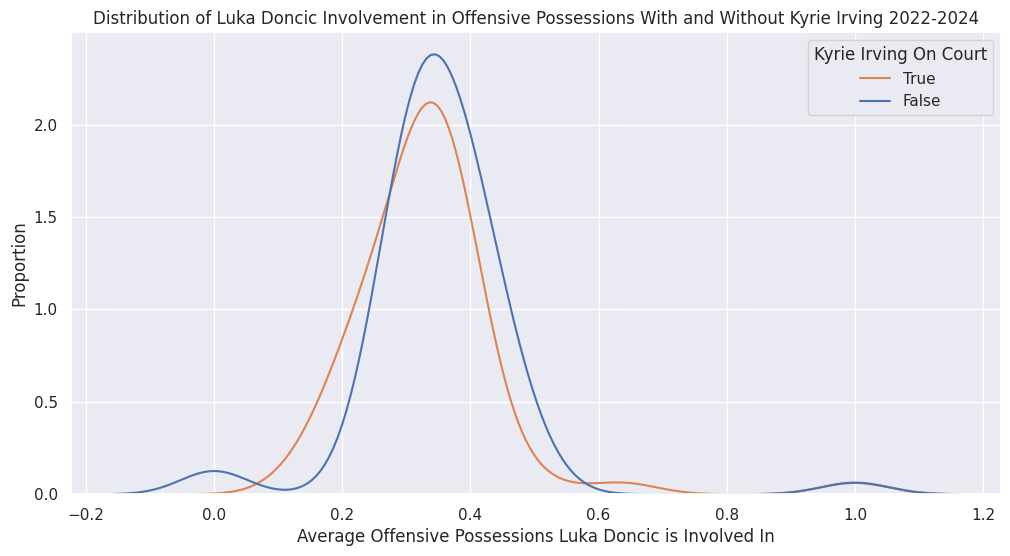

In [ ]:
# prompt: plot kde of db_involved for kd on and off

plt.figure(figsize=(12, 6))

sns.kdeplot(data=pivot_table_suns_off_luka_in, x='doncic_involved', hue='kyrie_on')

plt.xlabel('Average Offensive Possessions Luka Doncic is Involved In')
plt.ylabel('Proportion')
plt.title('Distribution of Luka Doncic Involvement in Offensive Possessions With and Without Kyrie Irving 2022-2024')
plt.legend(['True', 'False'], title='Kyrie Irving On Court')
plt.show()